Keyword Extraction Using KeyBERT.

Install the relevant packages.

In [3]:
from keybert import KeyBERT

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyBert starts by embedding a document into a vector by turning a chunk of text into a fixed sized vector which represents the semnatics of the document.
Extracts key words using simple techniques - count vectorizer, TFADF vectorizer
Embeds each word using the same model used to embed the document, leaving a list of keyword embeddings. 
Similarity measures will be calculated between document and keyword embeddings. This results in a vector, where each value is a similarity measure between the two. Sorts results in decreasing order to get the most simliar words. 

Adding diversity in the data:
Sometimes there is some redundancy in the data, and repetition. 
Max Sum Similarity
Maximal Marginal Relevance

In [4]:
model = KeyBERT(model = "distilbert-base-nli-mean-tokens")

One document PER Coordinate is needed for analysis

In [5]:
import pandas as pd

In [6]:
all_feedback = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\joinedfeedback.csv')
ratings = all_feedback.loc[:, ['Latitude', 'Longitude', 'q1', 'q2', 'q3', 'q4']]
responses =  all_feedback.loc[:, ['Latitude', 'Longitude', 'responseList']]

responses

,Latitude,Longitude,responseList
0,52.285500,-1.558030,"The route was busy with the public, but there ..."
1,52.286880,-1.533620,"There was a long, isolated road with a lack of..."
2,52.279250,-1.544650,"There was a long, isolated road with a lack of..."
3,52.290777,-1.533494,The route was busy with the public as there we...
4,52.275950,-1.516430,"Well-lit street, was quite busy with other mem..."
...,...,...,...
779,52.292370,-1.548190,A really nice walk to do in the evening.; The ...
780,52.285970,-1.536280,The route felt fairly safe with some street li...
781,52.282960,-1.545510,The route felt fairly safe with some street li...
782,52.288400,-1.538270,Walking through the park made me feel uneasy a...


Need to classify each coordinate to be safe/unsafe utilising user feedback. Used average of all answers to question 1 "How safe did you feel on the route?" 

In [7]:
classification_list = []
for index, row in ratings.iterrows():
    if row["q1"] > 2.5:
        classification_list.append("safe")
    else:
        classification_list.append("unsafe")

ratings["Classification"] = classification_list

ratings
ratings["Classification"].value_counts()

Classification
safe      413
unsafe    371
Name: count, dtype: int64

In [8]:
ratings['q2'] = ratings['q2'] / 5
ratings['q3'] = ratings['q3'] / 5
ratings['q4'] = ratings['q4'] / 5


In [9]:
ratings

,Latitude,Longitude,q1,q2,q3,q4,Classification
0,52.285500,-1.558030,3.0,0.80,0.80,0.20,safe
1,52.286880,-1.533620,3.0,0.60,0.40,0.20,safe
2,52.279250,-1.544650,3.0,0.60,0.40,0.20,safe
3,52.290777,-1.533494,3.5,0.75,0.80,0.35,safe
4,52.275950,-1.516430,3.0,0.60,0.60,0.20,safe
...,...,...,...,...,...,...,...
779,52.292370,-1.548190,3.0,0.55,0.65,0.40,safe
780,52.285970,-1.536280,2.5,0.40,0.30,0.20,unsafe
781,52.282960,-1.545510,2.5,0.40,0.30,0.20,unsafe
782,52.288400,-1.538270,2.0,0.40,0.20,0.20,unsafe


In [10]:
keywords_list = []

for index, row in responses.iterrows():
  
    doc = row["responseList"]

    keywords = model.extract_keywords(doc, keyphrase_ngram_range=(1,2), stop_words='english', use_mmr=True, diversity=0.9)

    keywords_list.append(keywords)

responses['Key words'] = keywords_list
    

In [98]:
keywords_list = []

for index, row in responses.iterrows():
  
    doc = row["responseList"]

    keywords = model.extract_keywords(doc, keyphrase_ngram_range=(1,2), stop_words='english', use_mmr=True, diversity=0.9)

    keywords_list.append(keywords)

responses['Keywords'] = keywords_list

In [99]:
responses

,Latitude,Longitude,responseList,Key words,Key words 3,Keywords
0,52.285500,-1.558030,"The route was busy with the public, but there ...","[(busy public, 0.5604), (lot cars, 0.3592), (u...","[(cars feel unsafe, 0.7099), (busy public, 0.5...","[(busy, 0.3785), (unsafe, 0.3211), (cars, 0.31..."
1,52.286880,-1.533620,"There was a long, isolated road with a lack of...","[(isolated road, 0.7717), (long isolated, 0.65...","[(long isolated road, 0.8514), (lack lighting ...","[(isolated, 0.57), (road, 0.5312), (long, 0.45..."
2,52.279250,-1.544650,"There was a long, isolated road with a lack of...","[(isolated road, 0.7717), (long isolated, 0.65...","[(long isolated road, 0.8514), (lack lighting ...","[(isolated, 0.57), (road, 0.5312), (long, 0.45..."
3,52.290777,-1.533494,The route was busy with the public as there we...,"[(parade safer, 0.4993), (shops needed, 0.3651...","[(busy public shops, 0.5989), (parade, 0.3846)...","[(parade, 0.3846), (shops, 0.2816), (nearby, 0..."
4,52.275950,-1.516430,"Well-lit street, was quite busy with other mem...","[(lit street, 0.7497), (busy members, 0.6292),...","[(public lit street, 0.7701), (street quite bu...","[(street, 0.5627), (public, 0.5542), (busy, 0...."
...,...,...,...,...,...,...
779,52.292370,-1.548190,A really nice walk to do in the evening.; The ...,"[(night drunk, 0.5259), (short sweet, 0.2917),...","[(park night drunk, 0.5805), (poorly lit 12am,...","[(drunk, 0.3404), (short, 0.2023), (12am, 0.13..."
780,52.285970,-1.536280,The route felt fairly safe with some street li...,"[(felt helpless, 0.381), (night route, 0.3066)...","[(park felt helpless, 0.581), (night route, 0....","[(helpless, 0.3453), (night, 0.2396), (park, 0..."
781,52.282960,-1.545510,The route felt fairly safe with some street li...,"[(felt helpless, 0.381), (night route, 0.3066)...","[(park felt helpless, 0.581), (night route, 0....","[(helpless, 0.3453), (night, 0.2396), (park, 0..."
782,52.288400,-1.538270,Walking through the park made me feel uneasy a...,"[(uneasy lighting, 0.5117), (walking park, 0.4...","[(park feel uneasy, 0.6819), (uneasy lighting,...","[(uneasy, 0.404), (walking, 0.3186), (park, 0...."


In [100]:
combined_df = pd.merge(ratings, responses, on=["Latitude", "Longitude"])

In [101]:
combined_df

,Latitude,Longitude,q1,q2,q3,q4,Classification,responseList,Key words,Key words 3,Keywords
0,52.285500,-1.558030,3.0,0.80,0.80,0.20,safe,"The route was busy with the public, but there ...","[(busy public, 0.5604), (lot cars, 0.3592), (u...","[(cars feel unsafe, 0.7099), (busy public, 0.5...","[(busy, 0.3785), (unsafe, 0.3211), (cars, 0.31..."
1,52.286880,-1.533620,3.0,0.60,0.40,0.20,safe,"There was a long, isolated road with a lack of...","[(isolated road, 0.7717), (long isolated, 0.65...","[(long isolated road, 0.8514), (lack lighting ...","[(isolated, 0.57), (road, 0.5312), (long, 0.45..."
2,52.279250,-1.544650,3.0,0.60,0.40,0.20,safe,"There was a long, isolated road with a lack of...","[(isolated road, 0.7717), (long isolated, 0.65...","[(long isolated road, 0.8514), (lack lighting ...","[(isolated, 0.57), (road, 0.5312), (long, 0.45..."
3,52.290777,-1.533494,3.5,0.75,0.80,0.35,safe,The route was busy with the public as there we...,"[(parade safer, 0.4993), (shops needed, 0.3651...","[(busy public shops, 0.5989), (parade, 0.3846)...","[(parade, 0.3846), (shops, 0.2816), (nearby, 0..."
4,52.275950,-1.516430,3.0,0.60,0.60,0.20,safe,"Well-lit street, was quite busy with other mem...","[(lit street, 0.7497), (busy members, 0.6292),...","[(public lit street, 0.7701), (street quite bu...","[(street, 0.5627), (public, 0.5542), (busy, 0...."
...,...,...,...,...,...,...,...,...,...,...,...
779,52.292370,-1.548190,3.0,0.55,0.65,0.40,safe,A really nice walk to do in the evening.; The ...,"[(night drunk, 0.5259), (short sweet, 0.2917),...","[(park night drunk, 0.5805), (poorly lit 12am,...","[(drunk, 0.3404), (short, 0.2023), (12am, 0.13..."
780,52.285970,-1.536280,2.5,0.40,0.30,0.20,unsafe,The route felt fairly safe with some street li...,"[(felt helpless, 0.381), (night route, 0.3066)...","[(park felt helpless, 0.581), (night route, 0....","[(helpless, 0.3453), (night, 0.2396), (park, 0..."
781,52.282960,-1.545510,2.5,0.40,0.30,0.20,unsafe,The route felt fairly safe with some street li...,"[(felt helpless, 0.381), (night route, 0.3066)...","[(park felt helpless, 0.581), (night route, 0....","[(helpless, 0.3453), (night, 0.2396), (park, 0..."
782,52.288400,-1.538270,2.0,0.40,0.20,0.20,unsafe,Walking through the park made me feel uneasy a...,"[(uneasy lighting, 0.5117), (walking park, 0.4...","[(park feel uneasy, 0.6819), (uneasy lighting,...","[(uneasy, 0.404), (walking, 0.3186), (park, 0...."


In [102]:
from collections import Counter

In [127]:
# Assuming combined_df is your DataFrame and it's already defined

# Explode keywords while filtering by classification
safe_keywords = combined_df[combined_df["Classification"] == "safe"]["Keywords"].explode()
unsafe_keywords = combined_df[combined_df["Classification"] == "unsafe"]["Keywords"].explode()

# Extract just the words, ignoring relevancy scores
safe_words = [keyword[0] for keyword in safe_keywords]
unsafe_words = [keyword[0] for keyword in unsafe_keywords]

# Generate word counts
safe_word_count = Counter(safe_words)
unsafe_word_count = Counter(unsafe_words)

# Extract top 10 most common words
top_safe_words = [keyword for keyword, count in safe_word_count.most_common(10)]
top_unsafe_words = [keyword for keyword, count in unsafe_word_count.most_common(10)]

print("Top 10 Safe Words:", top_safe_words)
print("Top 10 Unsafe Words:", top_unsafe_words)


Top 10 Safe Words: ['busy', 'route', 'walk', 'public', 'park', 'safe', 'daytime', 'cars', 'unsafe', 'lighting']
Top 10 Unsafe Words: ['lighting', 'park', 'night', 'hospital', 'nearby', 'shops', 'unsafe', 'isolated', 'walk', 'helpless']


ValueError: list.remove(x): x not in list

following code is to alter safety score based on presence of words:

In [129]:
# def adjust_safety_score(row, pos_keywords, neg_keywords, adjustment_factor=0.1):
#     # Assuming the initial safety score is in a column named 'safety_score'
#     initial_score = row['safety_score']
#     keywords = row['keywords_list']
    
#     # Check for the presence of top positive/negative keywords
#     pos_presence = any(keyword in keywords for keyword in pos_keywords)
#     neg_presence = any(keyword in keywords for keyword in neg_keywords)
    
#     # Adjust the score based on keyword presence
#     if pos_presence:
#         return initial_score * (1 + adjustment_factor)  # Increase by adjustment_factor
#     elif neg_presence:
#         return initial_score * (1 - adjustment_factor)  # Decrease by adjustment_factor
#     else:
#         return initial_score  # No change

# # Apply the adjustment function to each row
# joinedfeedback['adjusted_safety_score'] = joinedfeedback.apply(adjust_safety_score, args=(top_positive_keywords, top_negative_keywords), axis=1)


Getting crime data for this dataframe - creating new safety scores. 

In [149]:
crime_severity_scores = {
    "Drugs" : 2,
    "Shoplifting" : 2,
    "Burglary" : 5,
    "Theft from the person" : 8,
    "Possession of weapons" : 9,
    "Violence and sexual offences" : 10,
    "Criminal damage and arson" : 7,
    "Vehicle crime" : 4,
    "Bicycle theft " : 2,
    "Other theft" : 1,
    "Public order" : 1,
    "Robbery" : 5, 
    "Anti-social behaviour" : 5,
    "Other crime" : 1
}

In [150]:
import numpy as np 

In [151]:
def get_lat_lon_ranges(lat, lon, radius):
    # Earth's radius in meters
    EARTH_RADIUS = 6378137

    # Convert latitude and longitude from degrees to radians
    lat_rad = np.radians(lat)

    # Calculate deltas
    dLat = radius/EARTH_RADIUS
    dLon = radius/(EARTH_RADIUS * np.cos(lat_rad))

    # Convert deltas from radians to degrees
    dLat_deg = np.degrees(dLat)
    dLon_deg = np.degrees(dLon)

    # Define ranges
    lat_range = (lat - dLat_deg, lat + dLat_deg)
    lon_range = (lon - dLon_deg, lon + dLon_deg)

    return lat_range, lon_range

In [152]:
def get_crimes_in_range(all_crime_data, long_min, long_max, lat_min, lat_max, crime_severity_scores):
    # Filter the data to only include crimes within the specified ranges
    crimes_in_range = all_crime_data[
        (all_crime_data['Longitude'] >= long_min) & 
        (all_crime_data['Longitude'] <= long_max) & 
        (all_crime_data['Latitude'] >= lat_min) & 
        (all_crime_data['Latitude'] <= lat_max)
    ]

    crimes_in_range = crimes_in_range.copy()
    
    # Add severity score for each crime
    crimes_in_range['Severity Score'] = crimes_in_range['Crime type'].map(crime_severity_scores)
    # print(crimes_in_range)
    # Calculate average severity score for the crimes in the range
    
    if not crimes_in_range.empty:
        average_severity_score = crimes_in_range['Severity Score'].mean()
    else:
        average_severity_score = 0

    return len(crimes_in_range), average_severity_score

In [153]:
crime_data_2021 = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2021.csv")
crime_data_2022 = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2022.csv")
crime_data_2023 = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2023.csv")

In [154]:
def get_coords(dataframe):
    all_locations = [f"{row['Latitude']}, {row['Longitude']}" for index, row in dataframe.iterrows()]
    return [(float(lat), float(lon)) for lat, lon in (s.split(', ') for s in all_locations)]

coords = get_coords(combined_df)

print(len(coords))
coords

784


[(52.2855, -1.55803),
 (52.28688, -1.53362),
 (52.27925, -1.54465),
 (52.290777, -1.533494),
 (52.27595, -1.51643),
 (52.28569, -1.53394),
 (52.2760706, -1.5164124),
 (52.28398, -1.53755),
 (52.2913, -1.57789),
 (52.28414, -1.53665),
 (52.2843, -1.53489),
 (52.28377, -1.5404),
 (52.2866, -1.54848),
 (52.29140349999999, -1.5782611),
 (52.28624, -1.53316),
 (52.2818, -1.53485),
 (52.28959, -1.55339),
 (52.2851, -1.56291),
 (52.2762849, -1.5356019),
 (52.28728, -1.53574),
 (52.28541, -1.55786),
 (52.28725, -1.53562),
 (52.2899, -1.53796),
 (52.28806, -1.56727),
 (52.28694, -1.53704),
 (52.27543, -1.52666),
 (52.28681, -1.56078),
 (52.2948, -1.53725),
 (52.27632, -1.5322),
 (52.28503, -1.53542),
 (52.28789, -1.54591),
 (52.2875364, -1.541341),
 (52.27641, -1.52057),
 (52.28444, -1.53546),
 (52.28617, -1.55979),
 (52.28582, -1.53308),
 (52.29094, -1.57684),
 (52.28051, -1.53824),
 (52.28776, -1.56568),
 (52.28514, -1.53637),
 (52.2907119, -1.5829859),
 (52.28552, -1.56332),
 (52.29034, -1.5

In [155]:
# Gets a dictionary of all crimes, public space data for each coordinate in a 350m radius 
def create_dict(all_crime_data, all_coordinates, crime_severity_scores):
    coordinate_dict = {}
    for each in all_coordinates:
        coordinate_dict[each] = [0, 0]
        # Gets lat/lon range within a 50m radius
        lat_range, lon_range = get_lat_lon_ranges(each[0], each[1], 250)
        coordinate_dict[each][0], coordinate_dict[each][1] = get_crimes_in_range(all_crime_data, lon_range[0], lon_range[1], lat_range[0], lat_range[1], crime_severity_scores)
    return coordinate_dict

In [156]:
data_2021 = create_dict(crime_data_2021, coords, crime_severity_scores)
data_2022 = create_dict(crime_data_2021, coords, crime_severity_scores)
data_2023 = create_dict(crime_data_2021, coords, crime_severity_scores)

print(len(data_2021))

784


In [138]:
data_2021

{(52.2855, -1.55803): [5, 6.0],
 (52.28688, -1.53362): [622, 6.2901639344262295],
 (52.27925, -1.54465): [60, 5.566666666666666],
 (52.290777, -1.533494): [783, 4.902275769745649],
 (52.27595, -1.51643): [98, 6.204081632653061],
 (52.28569, -1.53394): [511, 6.351297405189621],
 (52.2760706, -1.5164124): [102, 6.264705882352941],
 (52.28398, -1.53755): [301, 6.285234899328859],
 (52.2913, -1.57789): [0, 0],
 (52.28414, -1.53665): [380, 6.874666666666666],
 (52.2843, -1.53489): [543, 6.5111940298507465],
 (52.28377, -1.5404): [164, 5.574074074074074],
 (52.2866, -1.54848): [34, 5.294117647058823],
 (52.29140349999999, -1.5782611): [0, 0],
 (52.28624, -1.53316): [571, 6.265124555160142],
 (52.2818, -1.53485): [252, 6.350597609561753],
 (52.28959, -1.55339): [66, 5.96969696969697],
 (52.2851, -1.56291): [62, 4.306451612903226],
 (52.2762849, -1.5356019): [212, 5.785714285714286],
 (52.28728, -1.53574): [495, 6.278008298755187],
 (52.28541, -1.55786): [5, 6.0],
 (52.28725, -1.53562): [497, 

Defines the weightings used to find the safety score.

In [157]:
# Original weights based on percentages
survey_weightings = {
    "crime": 95.9,
    "emergency": 80.2,
    "crowded": 78.2,
    "lighting": 85.4,
    "pos_keywords": 10, # Gave a percentage of 10 to start with. 
    "neg_keywords": -10 # Gave a percentage of 10 to start with. 
}

# Sum of the original weights
total_weight = sum(survey_weightings.values())

# Normalize each weight
normalized_weights = {k: v / total_weight for k, v in survey_weightings.items()}

print(normalized_weights)

{'crime': 0.28230791875183986, 'emergency': 0.2360906682366794, 'crowded': 0.23020312040035323, 'lighting': 0.25139829261112745, 'pos_keywords': 0.029437739181630847, 'neg_keywords': -0.029437739181630847}


In [167]:
# Function to calculate the safety score of a particular coordinate
def calculate_safety_score(max_crime, num_crime, emergency_rating, crowd_rating, 
                           unlit_rating, severity, weightings, keywords, pos_keywords, neg_keywords):
    
    safety_score = 0

    if num_crime > 0:
        safety_score += ((max_crime - num_crime) / max_crime) * weightings["crime"] * ((10 - severity) / 10)
    else:
        safety_score += weightings["crime"]
    
    if emergency_rating > 0:
        safety_score += (emergency_rating * weightings["emergency"])
    else: 
        safety_score -= weightings["emergency"]

    if crowd_rating > 0:
        safety_score += (crowd_rating * weightings["crowded"])
    else: 
        safety_score -= weightings["crowded"]

    if unlit_rating > 0:
        safety_score += (unlit_rating * weightings["lighting"])
    else: 
        safety_score -= weightings["lighting"]

    pos_count = sum(keywords.count(word) for word in pos_keywords)
    neg_count = sum(keywords.count(word) for word in neg_keywords)

    if pos_count > 0:
        pos_ratio = pos_count / len(pos_keywords)
        safety_score += (pos_ratio * weightings["pos_keywords"])

    if neg_count > 0:
        neg_ratio = neg_count / len(neg_keywords)
        safety_score += (neg_ratio * weightings["neg_keywords"])

    return safety_score * 100
    

In [174]:
def get_safety_scores(coords, max_crime, user_feedback, weightings, 
                      pos_keywords, neg_keywords, year, current_scores, output_file):
    safety_scores = []
    for coordinate, (crime_num, severity) in coords.items():
        lat = coordinate[0]
        lon = coordinate[1]

        emergency_rating = 0  # Assuming 0 as a default, adjust based on your logic
        crowd_rating = 0
        unlit_rating = 0
        # keywords = []

        matching_rows = user_feedback[(user_feedback["Longitude"] == lon) & (user_feedback["Latitude"] == lat)]

        if not matching_rows.empty:
            # Assuming you want the value from the first matching row
            unlit_rating = matching_rows["q2"].iloc[0]
            crowd_rating = matching_rows["q3"].iloc[0]
            emergency_rating = matching_rows["q4"].iloc[0]
            total_keywords = matching_rows["Keywords"].iloc[0]

            # Extract just the words, ignoring relevancy scores
            keywords = [keyword[0] for keyword in total_keywords]            

        safety_score = calculate_safety_score(max_crime, crime_num, emergency_rating, 
                                              crowd_rating, unlit_rating, severity, weightings, keywords, 
                                              pos_keywords, neg_keywords)
        
        safety_scores.append({
            "Latitude": lat,
            "Longitude": lon,
            "Lighting Rating": (unlit_rating / 5) * weightings["lighting"],
            "Crowd Rating": (crowd_rating / 5) * weightings["crowded"],
            "Emergency Rating": (emergency_rating / 5) * weightings["emergency"],
            "Crime Rate": ((max_crime - crime_num) / max_crime) * weightings["crime"],
            "Severity Score": (10 - severity) / 10,
            "Year": year,
            "Safety Score": safety_score
        })

    safety_df = pd.DataFrame(safety_scores)
    existing_df = pd.read_csv(current_scores)
    joined_df = pd.concat([existing_df, safety_df], ignore_index=True)
    joined_df.to_csv(output_file, index=False)

In [175]:
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\training_set_after.csv"

output_df = get_safety_scores(data_2021, len(crime_data_2021), combined_df, normalized_weights, 
                  top_safe_words, top_unsafe_words, 2021, output_file, output_file)

output_df2 = get_safety_scores(data_2022, len(crime_data_2022), combined_df, normalized_weights, 
                  top_safe_words, top_unsafe_words, 2022, output_file, output_file)


get_safety_scores(data_2023, len(crime_data_2023), combined_df, normalized_weights, 
                  top_safe_words, top_unsafe_words, 2023, output_file, output_file)

output = pd.read_csv(output_file)

output

,Latitude,Longitude,Safety Score,Year,Lighting Rating,Crowd Rating,Emergency Rating,Crime Rate,Severity Score
0,52.285500,-1.558030,55.546547,2021,0.040224,0.036832,0.009444,0.282066,0.400000
1,52.286880,-1.533620,38.437523,2021,0.030168,0.018416,0.009444,0.252256,0.370984
2,52.279250,-1.544650,41.466385,2021,0.030168,0.018416,0.009444,0.279409,0.443333
3,52.290777,-1.533494,57.408294,2021,0.037710,0.036832,0.016526,0.244477,0.509772
4,52.275950,-1.516430,44.808514,2021,0.030168,0.027624,0.009444,0.277573,0.379592
...,...,...,...,...,...,...,...,...,...
2347,52.292370,-1.548190,51.546333,2023,0.027654,0.029926,0.018887,0.276185,0.480833
2348,52.285970,-1.536280,29.637351,2023,0.020112,0.013812,0.009444,0.264735,0.318966
2349,52.282960,-1.545510,37.769528,2023,0.020112,0.013812,0.009444,0.275289,0.602143
2350,52.288400,-1.538270,30.465308,2023,0.020112,0.009208,0.009444,0.266129,0.414013


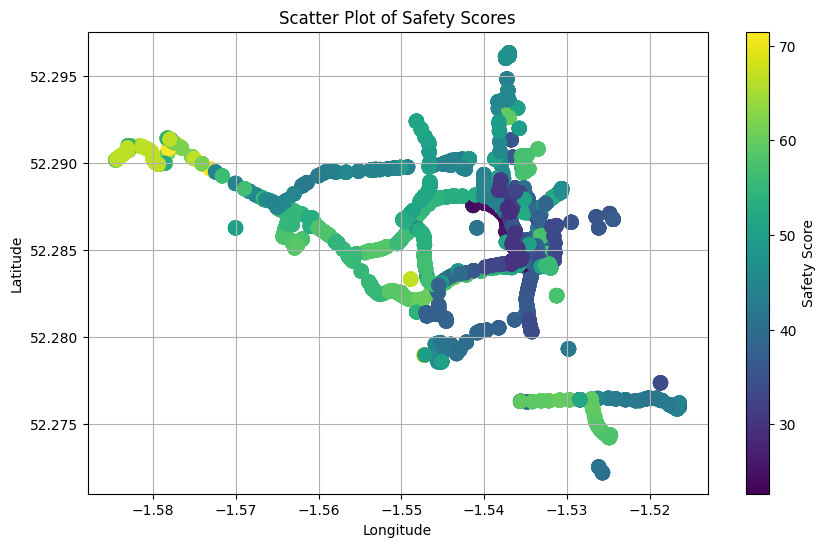

In [ ]:
import matplotlib.pyplot as plt

# Example DataFrame
df = pd.read_csv(output_file)
plt.figure(figsize=(10, 6))

# Scatter plot for safety scores
plt.scatter(df['Longitude'], df['Latitude'], c=df['Safety Score'], cmap='viridis', s=100)  # s is size
plt.colorbar(label='Safety Score')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Scatter Plot of Safety Scores')
plt.grid(True)
plt.show()

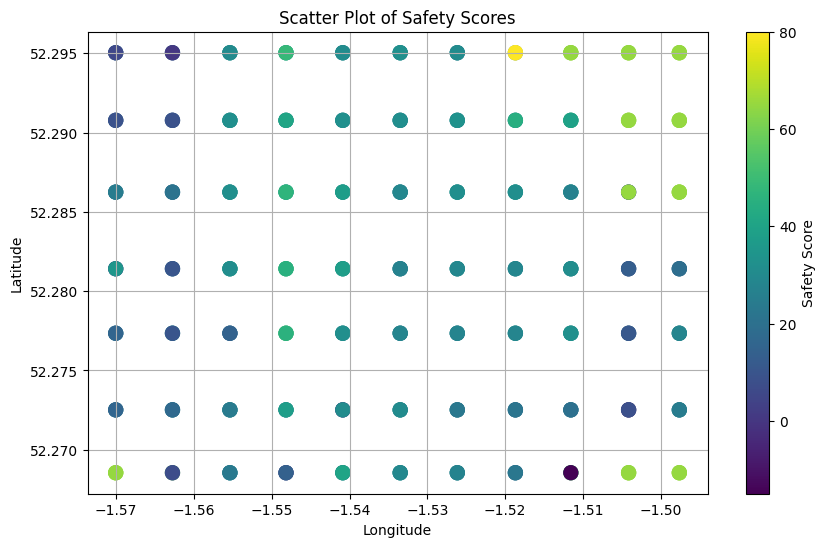

In [ ]:
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\training_set_new.csv"

# Example DataFrame
df = pd.read_csv(output_file)
plt.figure(figsize=(10, 6))

# Scatter plot for safety scores
plt.scatter(df['Longitude'], df['Latitude'], c=df['Safety Score'], cmap='viridis', s=100)  # s is size
plt.colorbar(label='Safety Score')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Scatter Plot of Safety Scores')
plt.grid(True)
plt.show()

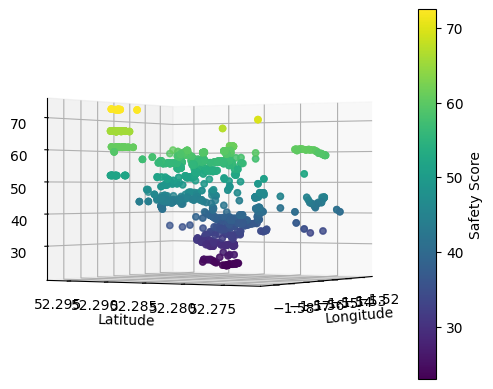

In [170]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with 'longitude', 'latitude', 'safety score'
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\training_set_after.csv"

df = pd.read_csv(output_file)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df['Longitude']
y = df['Latitude']
z = df['Safety Score']

# Scatter plot
sc = ax.scatter(x, y, z, c=z, cmap='viridis')  # Color by safety score, using a colormap
plt.colorbar(sc, label='Safety Score')  # Add colorbar to represent the safety score scale

# Setting the front view
ax.view_init(elev=0, azim=-150)  # Adjust azimuth for the desired front orientation


ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Safety Score')

plt.show()


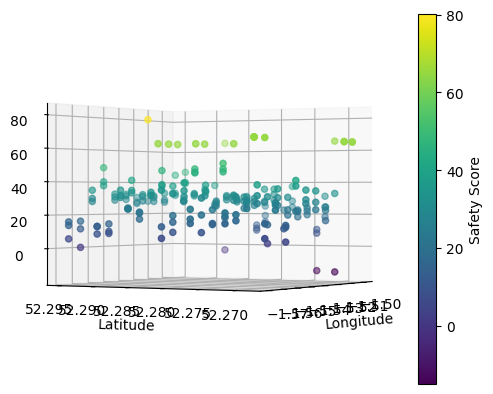

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with 'longitude', 'latitude', 'safety score'
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\training_set_new.csv"

df = pd.read_csv(output_file)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df['Longitude']
y = df['Latitude']
z = df['Safety Score']

# Scatter plot
sc = ax.scatter(x, y, z, c=z, cmap='viridis')  # Color by safety score, using a colormap
plt.colorbar(sc, label='Safety Score')  # Add colorbar to represent the safety score scale

# Setting the front view
ax.view_init(elev=0, azim=-150)  # Adjust azimuth for the desired front orientation


ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Safety Score')

plt.show()


In [ ]:
# Assuming df is your DataFrame with 'longitude', 'latitude', 'safety score'
output_file = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\safety_scores_after_feedback.csv"
df = pd.read_csv(output_file)
mean_scores = df.groupby(['Longitude', 'Latitude'])['Safety Score'].mean().reset_index()

output_f = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\avg_safety_scores.csv"

mean_scores.to_csv(output_f, index=False)

output_f


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\avg_safety_scores.csv'

Removing repetition - Max_sum similarity and Maximal Marginal Relevance.

In [ ]:
# keywords = model.extract_keywords(doc)
# model.extract_keywords(doc, keyphrase_ngram_range=(1,3), stop_words='english',
#                        use_maxsum=True, nr_candidates=20, top_n=4)
# model.extract_keywords(doc, keyphrase_ngram_range=(1,3), stop_words='english',
#                        use_mmr=True, diversity=0.9)